This notebook shows an example of how to generate a PAH emission spectrum using the single photon approximation (SPA) method described in Richie & Hensley (2025).

In [1]:
import astropy.units as u
import matplotlib as mpl
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pah_spec  # import the pah_spec module
from scipy.integrate import trapezoid

First, make sure that the required datasets are downloaded
- these functions exit early if the data was already retrieved
- downloads of some of the files can take a while since they are large (~1 GB). If the [tqdm package](https://tqdm.github.io/) is installed, a progressbar is shown

In [2]:
pah_spec.retrieve_internal_data()
pah_spec.retrieve_sample_basis()

Next, initialize the `PahSpec` object, which loads the $\tilde{p}_{\rm \lambda_{em}}(\lambda_{\rm abs})$ basis spectra into memory.

In [3]:
ps = pah_spec.PahSpec()

The `PahSpec` object has an attribute, `ps.grain_sizes`, specifying which PAH sizes the basis spectra correpond to. It also has attributes specifying the $\lambda_{\rm abs}$ and $\lambda_{\rm em}$ wavelengths the basis spectra are defind for: `ps.emission_wavelengths` and `ps.photon_wavelengths`.

It also has attributes for the basis spectra. Here's an example for a $5~{\rm \AA}$ PAH. The color corresponds to the wavelength of the absorbed photon $\lambda_{\rm abs}$, which ranges from $912~{\rm \AA}$ to $10~{\rm \mu m}$. There are 474 basis spectra in total for each grain size/ionization.

Text(0.5, 1.0, '$PAH^{0}$')

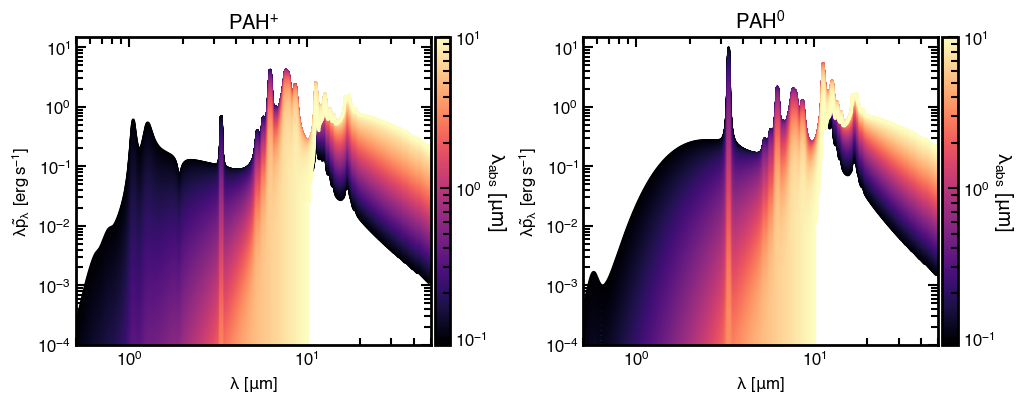

In [4]:
cmap = mpl.colormaps["magma"]
n_colors = len(ps.basis_spectra_ion[0])
sample_points = np.linspace(0, 1, n_colors)
color_list = cmap(sample_points)
wh_5 = np.argmin(np.abs(ps.grain_sizes - 5.012 * u.AA))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, _ in enumerate(ps.basis_spectra_ion[wh_5]):
    ax[0].loglog(
        ps.emission_wavelengths,
        ps.basis_spectra_ion[wh_5][i]
        * ps.emission_wavelengths.to(u.cm)
        / trapezoid(ps.basis_spectra_ion[wh_5][i], x=ps.emission_wavelengths.to(u.cm)),
        label=r"$PAH^+$",
        color=color_list[i],
    )

    ax[1].loglog(
        ps.emission_wavelengths,
        ps.basis_spectra_neu[wh_5][i]
        * ps.emission_wavelengths.to(u.cm)
        / trapezoid(ps.basis_spectra_neu[wh_5][i], x=ps.emission_wavelengths.to(u.cm)),
        label=r"$PAH^+$",
        color=color_list[i],
    )

norm = LogNorm(
    vmin=ps.photon_wavelengths.value.min(), vmax=ps.photon_wavelengths.value.max()
)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[0], pad=0.01)
cbar.set_label(label=r"$\lambda_{abs}~[\mu m]$", size=14, rotation=270, labelpad=15)
cbar = fig.colorbar(sm, ax=ax[1], pad=0.01)
cbar.set_label(label=r"$\lambda_{abs}~[\mu m]$", size=14, rotation=270, labelpad=15)
ax[0].set_xlim(0.5, 50)
ax[0].set_ylim(1e-4, 15)
ax[1].set_xlim(0.5, 50)
ax[1].set_ylim(1e-4, 15)
ax[0].set_xlabel(r"$\lambda~[\mu m]$")
ax[0].set_ylabel(r"$\lambda \tilde{p}_\lambda~[erg\,s^{-1}]$")
ax[1].set_xlabel(r"$\lambda~[\mu m]$")
ax[1].set_ylabel(r"$\lambda \tilde{p}_\lambda~[erg\,s^{-1}]$")
ax[0].set_title(r"$PAH^{+}$")
ax[1].set_title(r"$PAH^{0}$")

The primary functionality of the `PahSpec` object is the method `PahSpec.generate_spectrum()`, which takes a radiation field and combined size distribution/ionization function as inputs and returns a PAH emission sepctrum calculated using the SPA method as output.

In [5]:
print(ps.generate_spectrum.__doc__)

Scale the basis spectra for ionized and neutral PAHs to an input radiation field and integrate
over the size distribution.

Parameters
----------
wavelength_arr : astropy.units.Quantity (array_like), optional
    Wavelength array for the radiation field u_lambda (in u.um)
u_lambda_arr : astropy.units.Quantity (array_like), optional
    Array of length len(wavelength_arr) with the radiation field (in u.erg / u.cm ** 4)
size_dist_neu : array_like, optional
    PAH0 size distribution and ionization function for each grain size in self.grain_sizes
size_dist_ion : array_like, optional
    PAH+ size distribution and ionization function for each grain size in self.grain_sizes

Returns
-------
spectrum_neu : astropy.units.Quantity (array_like)
    PAH0 size- and ionization-integrated spectrum for grains heated by the input u_lambda
    (in u.erg / (u.cm * u.s))
spectrum_ion : astropy.units.Quantity (array_like)
    PAH+ size- and ionization-integrated spectrum for grains heated by the input u_

The instance of the `PahSpec` object has attributes defining the default size/ionization function and the radiation field: `ps.size_dist_ion`, `ps.size_dist_neu`, `ps.wavelength_u_arr`, and `ps.u_lambda_arr`.

The default size distribution and ionization function are set to the standard values from [Draine et al. (2021)](https://ui.adsabs.harvard.edu/abs/2021ApJ...917....3D/abstract). The default radiation field is the modified [Mathis, Mezger, and Panagia (1983)](https://ui.adsabs.harvard.edu/abs/1983A%26A...128..212M/abstract) radiation field, described in [Draine et al. (2011)](https://ui.adsabs.harvard.edu/abs/2011piim.book.....D/abstract).

Text(0.5, 1.0, 'Default radiation field')

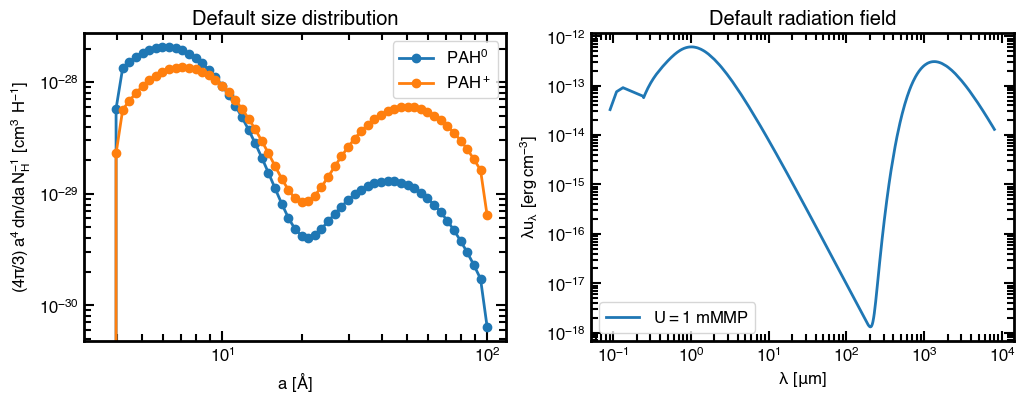

In [21]:
dlna = np.log(ps.grain_sizes[-1] / ps.grain_sizes[0]) / len(ps.grain_sizes)
dnda_neu = ps.size_dist_neu / (dlna * ps.grain_sizes.to(u.cm))
dnda_ion = ps.size_dist_ion / (dlna * ps.grain_sizes.to(u.cm))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].loglog(
    ps.grain_sizes,
    dnda_neu * np.pi * (4 / 3) * ps.grain_sizes.to(u.cm) ** 4,
    marker="o",
    label=r"$PAH^0$"
)
ax[0].loglog(
    ps.grain_sizes,
    dnda_ion * np.pi * (4 / 3) * ps.grain_sizes.to(u.cm) ** 4,
    marker="o",
    label=r"$PAH^+$"
)
ax[0].legend()
ax[0].set_xlabel(r"$a~[\AA]$")
ax[0].set_ylabel(r"$(4\pi/3)\,a^4\,dn/da\,N_H^{-1}~[cm^3~H^{-1}]$")
ax[0].set_title("Default size distribution")

ax[1].loglog(
    ps.wavelength_u_arr,
    ps.u_lambda_arr * ps.wavelength_u_arr.to(u.cm),
    label=r"$U=1$ mMMP",
)
ax[1].legend()
ax[1].set_xlabel(r"$\lambda~[\mu m]$")
ax[1].set_ylabel(r"$\lambda u_\lambda~[erg\,cm^{-3}]$")
ax[1].set_title("Default radiation field")

`pah_spec` also provides a function, `calc_dn`, which can be used to customize the grain size distribution.

In [7]:
print(pah_spec.calc_dn.__doc__)

Calculates the size distribution dn for ionized and neutral PAHs, following the definitions in
Sections 6.1 and 6.2 of Draine et al. (2021).

Parameters
----------
grain_sizes : astropy.units.Quantity (array-like)
    Array of grain sizes to compute size distribution for, uniformly spaced in log(grain_sizes)
size_dist : str, optional
    Specifies the PAH sizes. Options are "sm", "st" (default), and "lg".
ion_frac : str, optional
    Specifies the fraction of ionized/neutral PAHs. Options are "lo", "st" (default), and "hi".

Returns
-------
dn_neu : astropy.units.Quantity (array-like)
    The number of neutral PAHs in each size bin (in units of 1 / H atom)
dn_ion : astropy.units.Quantity (array-like)
    The number of ionized PAHs in each size bin (in units of 1 / H atom)



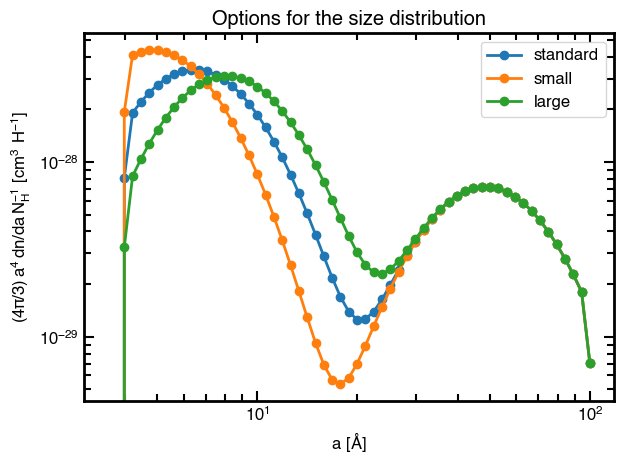

In [8]:
dnda_st_st = np.sum(pah_spec.calc_dn(ps.grain_sizes), axis=0) / (dlna * ps.grain_sizes.to(u.cm))
dnda_sm_st = np.sum(pah_spec.calc_dn(ps.grain_sizes, size_dist="sm"), axis=0) / (dlna * ps.grain_sizes.to(u.cm))
dnda_lg_st = np.sum(pah_spec.calc_dn(ps.grain_sizes, size_dist="lg"), axis=0) / (dlna * ps.grain_sizes.to(u.cm))

plt.loglog(ps.grain_sizes, dnda_st_st * np.pi * (4 / 3) * ps.grain_sizes.to(u.cm) ** 4, marker="o", label="standard")
plt.loglog(ps.grain_sizes, dnda_sm_st * np.pi * (4 / 3) * ps.grain_sizes.to(u.cm) ** 4, marker="o", label="small")
plt.loglog(ps.grain_sizes, dnda_lg_st * np.pi * (4 / 3) * ps.grain_sizes.to(u.cm) ** 4, marker="o", label="large")

plt.title("Options for the size distribution")
plt.xlabel(r"$a~[\AA]$")
plt.ylabel(r"$(4\pi/3)\,a^4\,dn/da\,N_H^{-1}~[cm^3~H^{-1}]$")
plt.legend()
plt.tight_layout()

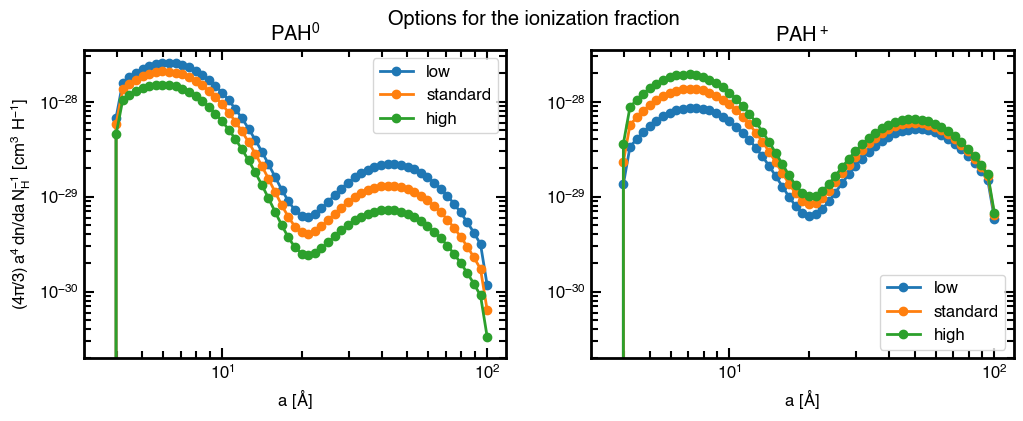

In [9]:
dnda_st_lo = pah_spec.calc_dn(ps.grain_sizes, ion_frac="lo") / (dlna * ps.grain_sizes.to(u.cm))
dnda_st_st = pah_spec.calc_dn(ps.grain_sizes) / (dlna * ps.grain_sizes.to(u.cm))
dnda_st_hi = pah_spec.calc_dn(ps.grain_sizes, ion_frac="hi") / (dlna * ps.grain_sizes.to(u.cm))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].loglog(ps.grain_sizes, dnda_st_lo[0] * np.pi * (4 / 3) * ps.grain_sizes.to(u.cm) ** 4, marker="o", label="low")
ax[0].loglog(ps.grain_sizes, dnda_st_st[0] * np.pi * (4 / 3) * ps.grain_sizes.to(u.cm) ** 4, marker="o", label="standard")
ax[0].loglog(ps.grain_sizes, dnda_st_hi[0] * np.pi * (4 / 3) * ps.grain_sizes.to(u.cm) ** 4, marker="o", label="high")

ax[1].loglog(ps.grain_sizes, dnda_st_lo[1] * np.pi * (4 / 3) * ps.grain_sizes.to(u.cm) ** 4, marker="o", label="low")
ax[1].loglog(ps.grain_sizes, dnda_st_st[1] * np.pi * (4 / 3) * ps.grain_sizes.to(u.cm) ** 4, marker="o", label="standard")
ax[1].loglog(ps.grain_sizes, dnda_st_hi[1] * np.pi * (4 / 3) * ps.grain_sizes.to(u.cm) ** 4, marker="o", label="high")

fig.suptitle("Options for the ionization fraction")
ax[0].set_title(r"$PAH^0$")
ax[1].set_title(r"$PAH^+$")
ax[0].set_xlabel(r"$a~[\AA]$")
ax[1].set_xlabel(r"$a~[\AA]$")
ax[0].set_ylabel(r"$(4\pi/3)\,a^4\,dn/da\,N_H^{-1}~[cm^3~H^{-1}]$")
ax[0].set_ylim(2e-31, 3.5e-28)
ax[1].set_ylim(2e-31, 3.5e-28)
ax[0].legend()
ax[1].legend()

First, generate a spectrum using the default setting.

In [10]:
spectrum_neu_mmp, spectrum_ion_mmp = ps.generate_spectrum()

(1e-27, 4e-24)

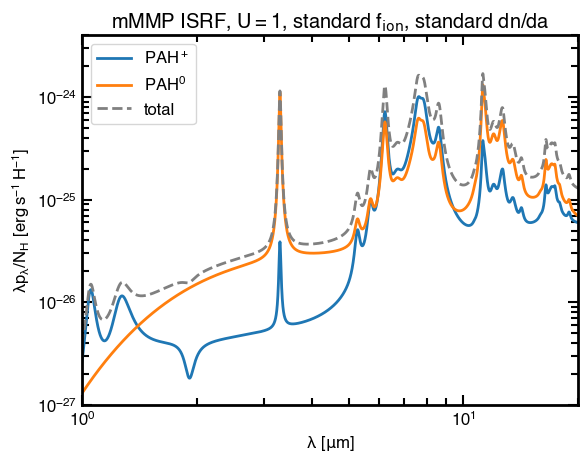

In [11]:
plt.loglog(
    ps.emission_wavelengths,
    spectrum_ion_mmp * ps.emission_wavelengths.to(u.cm),
    label=r"$PAH^+$",
)
plt.loglog(
    ps.emission_wavelengths,
    spectrum_neu_mmp * ps.emission_wavelengths.to(u.cm),
    label=r"$PAH^0$",
)
plt.loglog(
    ps.emission_wavelengths,
    (spectrum_ion_mmp + spectrum_neu_mmp) * ps.emission_wavelengths.to(u.cm),
    label="total",
    linestyle="--",
    color="grey",
)
plt.legend()
plt.xlabel(r"$\lambda~[\mu m]$")
plt.ylabel(r"$\lambda p_\lambda/N_H~[erg\,s^{-1}\,H^{-1}]$")
plt.title(r"mMMP ISRF, $U=1$, standard $f_{\rm ion}$, standard $dn/da$")
plt.xlim(1, 20)
plt.ylim(1e-27, 4e-24)

As an example of passing in a custom radiation field, we can specify the `wavelength_arr` and `u_lambda_arr` arguments of `ps.generate_spectrum()`. We'll use the Z=0.02, 10 Myr BC03 radiation field, which can be found on the [Draine et al. (2021) Harvard Dataverse](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/LPUHIQ). Note that the minimum wavelength that will contribute to PAH heating is $912~{\rm \AA}$ and the maximum is $10~{\rm \mu m}$.

We can also specify the `size_dist_neu` and `size_dist_ion` arguments of `ps.generate_spectrum()` to change the grain size distribution/ionization fraction. `ps.generate_spectrum()` expects the size distributions in the form of $f_{\rm ion}\,dn$ for ions and $(1-f_{\rm ion})\,dn$ for neutrals, where $f_{\rm ion}\in[0,1]$ and the expected units of $dn$ are 1 / H atom (see Eq. 15 of [Draine et al. 2021](https://ui.adsabs.harvard.edu/abs/2021ApJ...917....3D/abstract) for details).

In [12]:
# Read in Z=0.02, 10 Myr BC03 radiation field from Draine et al. (2021)
df = pd.read_csv(
    os.path.join("../data/defaults/isrf_bc03_z0.02_1e7_0.00"), sep="\\s+", skiprows=6
)
wavelength_u_arr_bc03 = df["(um)"].to_numpy() * u.um
u_lambda_arr_bc03 = (
    df["(erg"].to_numpy() * (u.erg / u.cm**3) / wavelength_u_arr_bc03.to(u.cm)
)

# define size distribution
dn_sm_hi = pah_spec.calc_dn(ps.grain_sizes, size_dist="sm", ion_frac="hi")

Text(0.5, 1.0, '$U=1$ 10 Myr BC03 radiation field')

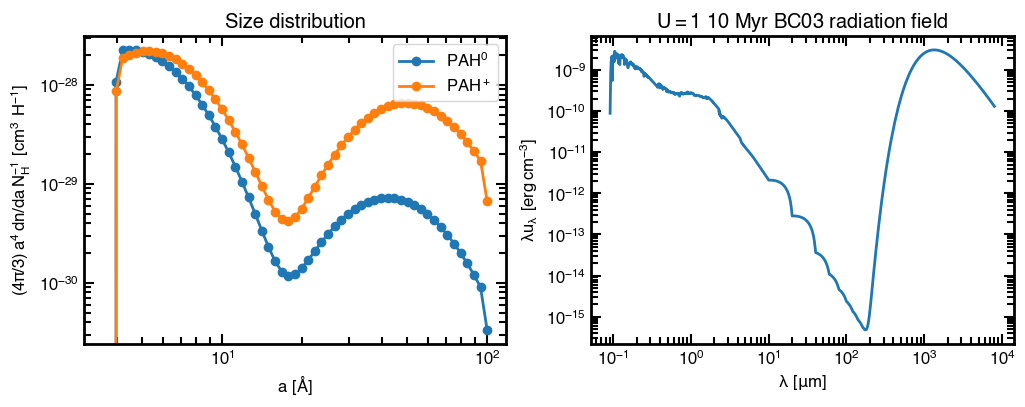

In [19]:
dnda_sm_hi_neu = dn_sm_hi[0] / (dlna * ps.grain_sizes.to(u.cm))
dnda_sm_hi_ion = dn_sm_hi[1] / (dlna * ps.grain_sizes.to(u.cm))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].loglog(
    ps.grain_sizes,
    dnda_sm_hi_neu * np.pi * (4 / 3) * ps.grain_sizes.to(u.cm) ** 4,
    marker="o",
    label=r"$PAH^0$"
)
ax[0].loglog(
    ps.grain_sizes,
    dnda_sm_hi_ion * np.pi * (4 / 3) * ps.grain_sizes.to(u.cm) ** 4,
    marker="o",
    label=r"$PAH^+$"
)
ax[0].legend()
ax[0].set_xlabel(r"$a~[\AA]$")
ax[0].set_ylabel(r"$(4\pi/3)\,a^4\,dn/da\,N_H^{-1}~[cm^3~H^{-1}]$")
ax[0].set_title("Size distribution")

ax[1].loglog(
    wavelength_u_arr_bc03,
    u_lambda_arr_bc03 * wavelength_u_arr_bc03,
)
ax[1].set_xlabel(r"$\lambda~[\mu m]$")
ax[1].set_ylabel(r"$\lambda u_\lambda~[erg\,cm^{-3}]$")
ax[1].set_title(r"$U=1$ 10 Myr BC03 radiation field")

In [13]:
# specify the radiation field and size distribution arguments
spectrum_neu_bc03, spectrum_ion_bc03 = ps.generate_spectrum(
    wavelength_arr=wavelength_u_arr_bc03, u_lambda_arr=u_lambda_arr_bc03, size_dist_neu=dn_sm_hi[0], size_dist_ion=dn_sm_hi[1]
)

(1e-27, 4e-24)

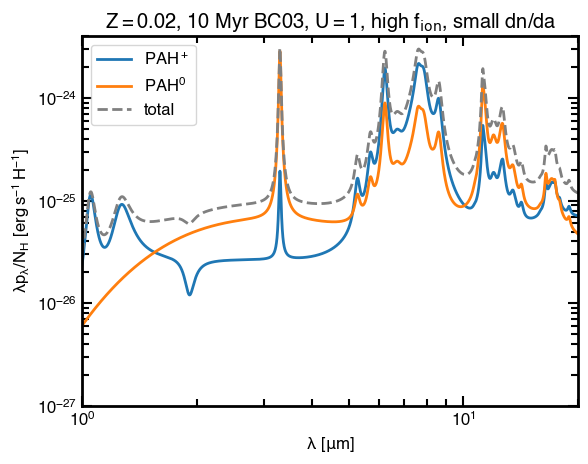

In [14]:
plt.loglog(
    ps.emission_wavelengths,
    spectrum_ion_bc03 * ps.emission_wavelengths.to(u.cm),
    label=r"$PAH^+$",
)
plt.loglog(
    ps.emission_wavelengths,
    spectrum_neu_bc03 * ps.emission_wavelengths.to(u.cm),
    label=r"$PAH^0$",
)
plt.loglog(
    ps.emission_wavelengths,
    (spectrum_ion_bc03 + spectrum_neu_bc03) * ps.emission_wavelengths.to(u.cm),
    label="total",
    linestyle="--",
    color="grey",
)
plt.legend()
plt.xlabel(r"$\lambda~[\mu m]$")
plt.ylabel(r"$\lambda p_\lambda/N_H~[erg\,s^{-1}\,H^{-1}]$")
plt.title(r"$Z=0.02$, 10 Myr BC03, $U=1$, high $f_{\rm ion}$, small $dn/da$")
plt.xlim(1, 20)
plt.ylim(1e-27, 4e-24)